<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Demography_Migration_MADDPG_GDM_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# -*- coding: utf-8 -*-
"""
Colab notebook for modeling population policy
using multi-agent reinforcement learning (MADDPG) and evolutionary algorithms.

Main goal: optimization of population policy in Russian regions using a
hybrid approach combining reinforcement learning methods and evolutionary algorithms.

"""
# Import libraries for numerical computations (numpy), data manipulation (pandas)
import numpy as np
import pandas as pd
# Import PyTorch library for building and training neural networks
import torch
import torch.nn as nn # Neural network modules
import torch.optim as optim # Optimization algorithms
import torch.nn.functional as F # Activation functions and other utilities
# Import data structures (defaultdict, deque) and the random number generation module (random)
from collections import defaultdict, deque
import random
# Import modules for working with JSON, plotting (matplotlib, seaborn)
import json
import matplotlib.pyplot as plt
import seaborn as sns
# Import module for working with dates and time
from datetime import datetime
# Import module for managing warnings
import warnings
warnings.filterwarnings('ignore') # Ignore all warnings

# Setting random seeds for reproducibility of experimental results
np.random.seed(42) # Seed for numpy
torch.manual_seed(42) # Seed for PyTorch CPU
random.seed(42) # Seed for the standard random module

In [11]:
class SyntheticDataGenerator:
    """Synthetic Data Generator Based on Real Demographic Data"""
    # Class constructor, initializes the generator with data
    def __init__(self, real_data_path, crisis_scenarios_path):
        self.df = pd.read_csv(real_data_path) # Load real demographic data from CSV
        # Open and load crisis scenarios from a JSON file
        with open(crisis_scenarios_path, 'r') as f:
            self.crisis_scenarios = json.load(f)
        self.preprocess_data() # Call the data preprocessing method

    # Method for preprocessing real data and calculating statistics
    def preprocess_data(self):
        """Preprocessing of real data for simulation"""
        # Normalize data and calculate statistics
        self.region_stats = {} # Dictionary to store statistics for regions
        # Iterate through unique region names in the data
        for region in self.df['region_name'].unique():
            # Select data only for the current region
            region_data = self.df[self.df['region_name'] == region]
            # Calculate and store statistical indicators for the region
            self.region_stats[region] = {
                'birth_rate_mean': region_data['birth_rate'].mean(), # Mean birth rate
                'birth_rate_std': region_data['birth_rate'].std(), # Standard deviation of birth rate
                'death_rate_mean': region_data['death_rate'].mean(), # Mean death rate
                'death_rate_std': region_data['death_rate'].std(), # Standard deviation of death rate
                'migration_mean': region_data['migration_balance'].mean(), # Mean migration balance
                'migration_std': region_data['migration_balance'].std(), # Standard deviation of migration
                'gdp_mean': region_data['gdp_per_capita'].mean(), # Mean GDP per capita
                'gdp_std': region_data['gdp_per_capita'].std(), # Standard deviation of GDP
                'unemployment_mean': region_data['unemployment_rate'].mean(), # Mean unemployment rate
                'unemployment_std': region_data['unemployment_rate'].std(), # Standard deviation of unemployment
                'population_trend': self._calculate_trend(region_data['population']), # Population trend
                'region_id': region_data['region_id'].iloc[0] # Region identifier
            }

    # Method for calculating the trend of a time series (slope coefficient)
    def _calculate_trend(self, series):
        """Calculation of the time series trend"""
        x = np.arange(len(series)) # Create an array of indices (years)
        z = np.polyfit(x, series, 1) # Linear regression (1st degree polynomial)
        return z[0]  # Return the slope coefficient

    # Method for applying the impact of a crisis on demographic indicators
    def apply_crisis_impact(self, base_values, crisis_scenario, year, crisis_start_year):
        """Application of crisis impact on demographic indicators"""
        crisis_duration = year - crisis_start_year + 1 # Crisis duration in years
        max_duration = crisis_scenario['end_year'] - crisis_scenario['start_year'] + 1 # Max duration
        # Crisis intensity decays over time (from 1 to 0)
        intensity = max(0, 1 - (crisis_duration - 1) / max_duration)
        impacts = crisis_scenario['demographic_impacts'] # Get crisis impacts
        # Calculate impacts on each indicator
        birth_rate_impact = impacts['birth_rate_change'] * intensity # Impact on birth rate
        death_rate_impact = impacts['death_rate_change'] * intensity # Impact on death rate
        migration_impact = impacts['migration_change'] * intensity # Impact on migration
        economic_impact = impacts['economic_impact'] * intensity # Economic impact
        modified_values = base_values.copy() # Copy of base values for modification
        # Apply impacts to indicators
        modified_values['birth_rate'] *= (1 + birth_rate_impact) # Modify birth rate
        modified_values['death_rate'] *= (1 + death_rate_impact) # Modify death rate
        modified_values['migration_balance'] *= (1 + migration_impact) # Modify migration
        modified_values['gdp_per_capita'] *= (1 + economic_impact) # Modify GDP
        modified_values['unemployment_rate'] *= (1 - economic_impact * 0.5) # Modify unemployment
        return modified_values # Return modified values

    # Method for generating synthetic demographic data
    def generate_synthetic_data(self, years, regions, apply_crisis=True):
        """Generation of synthetic demographic data"""
        synthetic_data = [] # List to store generated data
        # Iterate through all years
        for year in years:
            # Iterate through all regions
            for region in regions:
                # Check if statistics exist for the region
                if region not in self.region_stats:
                    continue # Skip region if statistics are missing
                stats = self.region_stats[region] # Get region statistics
                # Generate base values based on statistics (normal distribution)
                base_values = {
                    'region_id': stats['region_id'], # Region identifier
                    'region_name': region, # Region name
                    'year': year, # Year
                    # Birth rate (normal distribution, not less than 0)
                    'birth_rate': max(0, np.random.normal(stats['birth_rate_mean'], stats['birth_rate_std'])),
                    # Death rate (normal distribution, not less than 0)
                    'death_rate': max(0, np.random.normal(stats['death_rate_mean'], stats['death_rate_std'])),
                    # Migration balance (normal distribution)
                    'migration_balance': np.random.normal(stats['migration_mean'], stats['migration_std']),
                    # GDP per capita (normal distribution, not less than 0)
                    'gdp_per_capita': max(0, np.random.normal(stats['gdp_mean'], stats['gdp_std'])),
                    # Unemployment rate (normal distribution, from 0 to 100)
                    'unemployment_rate': max(0, min(100, np.random.normal(stats['unemployment_mean'], stats['unemployment_std'])))
                }
                # Application of crisis scenarios, if allowed
                if apply_crisis:
                    # Iterate through all crisis scenarios
                    for scenario in self.crisis_scenarios:
                        # Check if the year falls within the crisis period
                        if scenario['start_year'] <= year <= scenario['end_year']:
                            # Apply crisis impact to base values
                            base_values = self.apply_crisis_impact(
                                base_values, scenario, year, scenario['start_year']
                            )
                # Calculation of derived indicators
                # Natural population increase (births - deaths)
                base_values['natural_increase_rate'] = base_values['birth_rate'] - base_values['death_rate']
                # Base population with trend
                base_population = 1000000 + stats['population_trend'] * (year - 2010)
                # Total population (not less than 0)
                base_values['population'] = max(0, int(base_population +
                    (base_values['natural_increase_rate'] + base_values['migration_balance']/1000) * 1000))
                # Average wage, correlated with GDP and unemployment
                base_values['average_wage'] = max(0, base_values['gdp_per_capita'] * 0.03 *
                                                (1 - base_values['unemployment_rate']/100))
                synthetic_data.append(base_values) # Add generated data to the list
        # Convert the list of dictionaries to a pandas DataFrame and return
        return pd.DataFrame(synthetic_data)

In [12]:
class DemographicEnvironment:
    """Multi-Agent Environment for Demographic Modeling"""
    # Class constructor, initializes the environment
    def __init__(self, data, n_regions=10, max_steps=50):
        self.data = data # Store demographic data
        # Get the first n_regions unique region names
        self.regions = data['region_name'].unique()[:n_regions]
        self.n_regions = len(self.regions) # Number of regions (agents)
        self.max_steps = max_steps # Maximum number of steps in an episode
        self.current_step = 0 # Current step in the episode
        # Dimensions of state and action spaces
        self.state_dim = 8  # main demographic indicators (8 parameters)
        self.action_dim = 4  # policy actions (4 types of actions)
        self.reset() # Reset the environment to the initial state

    # Method to reset the environment to the initial state
    def reset(self):
        """Reset the environment to the initial state"""
        self.current_step = 0 # Reset the step counter
        self.states = {} # Dictionary to store current states of regions
        # Dictionary to store the history of each region
        self.histories = {region: [] for region in self.regions}
        # Initialize states of all regions
        for i, region in enumerate(self.regions):
            # Get data for the region for the initial year
            region_data = self.data[self.data['region_name'] == region].iloc[0]
            # Normalize and save the initial state of the region
            self.states[region] = self._normalize_state(region_data)
        return self.get_observations() # Return initial observations

    # Method for normalizing the state of a region
    def _normalize_state(self, region_data):
        """Normalization of region state"""
        # Create a normalized state array
        return np.array([
            region_data['birth_rate'] / 20.0, # Normalize birth rate (up to 20)
            region_data['death_rate'] / 30.0, # Normalize death rate (up to 30)
            region_data['natural_increase_rate'] / 10.0, # Normalize natural increase (up to 10)
            # Normalize migration balance (up to 100000, max 1.0)
            min(region_data['migration_balance'] / 100000.0, 1.0),
            region_data['gdp_per_capita'] / 2000000.0, # Normalize GDP per capita (up to 2 million)
            region_data['unemployment_rate'] / 100.0, # Normalize unemployment rate (up to 100%)
            region_data['population'] / 10000000.0, # Normalize population (up to 10 million)
            region_data['average_wage'] / 200000.0 # Normalize average wage (up to 200k)
        ])

    # Method for obtaining observations for all agents
    def get_observations(self):
        """Obtaining observations for all agents"""
        observations = {} # Dictionary to store observations
        # Iterate through all regions
        for region in self.regions:
            # Local observation (state of the current region)
            obs = self.states[region].copy()
            # Collect states of other regions
            other_states = [self.states[r] for r in self.regions if r != region]
            # Add averaged information about other regions
            if other_states: # If there are other regions
                avg_other = np.mean(other_states, axis=0) # Average their states
                obs = np.concatenate([obs, avg_other]) # Concatenate local and average states
            else: # If it's a single region
                obs = np.concatenate([obs, np.zeros(self.state_dim)]) # Add zeros
            observations[region] = obs # Save observation for the region
        return observations # Return all observations

    # Method for executing a step in the environment
    def step(self, actions):
        """Executing a step in the environment"""
        rewards = {} # Dictionary to store rewards
        # Iterate through all regions
        for region in self.regions:
            # Check if there is an action for the region
            if region in actions:
                action = actions[region] # Get the action
                old_state = self.states[region].copy() # Save the old state
                # Update the region's state based on the action
                self.states[region] = self._apply_policy_action(self.states[region], action)
                # Calculate reward for the transition from old state to new
                rewards[region] = self._calculate_reward(old_state, self.states[region])
                # Save step history
                self.histories[region].append({
                    'step': self.current_step, # Step number
                    'state': old_state.copy(), # Old state
                    'action': action.copy(), # Performed action
                    'reward': rewards[region] # Received reward
                })
        self.current_step += 1 # Increment the step counter
        done = self.current_step >= self.max_steps # Check if the episode is finished
        # Return new observations, rewards, done flag, and an empty dictionary
        return self.get_observations(), rewards, done, {}

    # Method for applying policy actions to a region's state
    def _apply_policy_action(self, state, action):
        """Application of policy actions to a region's state"""
        new_state = state.copy() # Copy of the current state
        # action[0] - maternal capital (affects birth rate)
        # action[1] - healthcare (affects death rate)
        # action[2] - migration policy (affects migration)
        # action[3] - economic stimuli (affects GDP and unemployment)
        birth_rate_change = action[0] * 0.1 # Birth rate change from maternal capital
        death_rate_change = -action[1] * 0.05 # Death rate change from healthcare
        migration_change = action[2] * 0.05 # Migration change from migration policy
        economic_change = action[3] * 0.02 # Economic indicator change
        # Update indicators considering actions and constraints (not less than 0)
        new_state[0] = max(0, new_state[0] + birth_rate_change)  # birth_rate
        new_state[1] = max(0, new_state[1] + death_rate_change)  # death_rate
        new_state[2] = new_state[0] - new_state[1]  # natural_increase_rate (recalculation)
        new_state[3] = new_state[3] + migration_change  # migration_balance
        new_state[4] = max(0, new_state[4] + economic_change)  # gdp_per_capita
        # Update unemployment rate (from 0 to 1)
        new_state[5] = max(0, min(1, new_state[5] - economic_change * 0.5))  # unemployment_rate
        # Update population
        population_change = (new_state[2] + new_state[3]) * 0.01
        new_state[6] = max(0, new_state[6] + population_change) # population
        # Update average wage
        new_state[7] = new_state[4] * 0.1 * (1 - new_state[5]) # average_wage
        return new_state # Return the new state

    # Method for calculating reward based on improvement of demographic indicators
    def _calculate_reward(self, old_state, new_state):
        """Calculation of reward based on the improvement of demographic indicators"""
        # Positive changes in indicators (with weights)
        birth_rate_improvement = (new_state[0] - old_state[0]) * 10 # Birth rate improvement
        death_rate_improvement = (old_state[1] - new_state[1]) * 10 # Death rate improvement
        natural_increase_improvement = (new_state[2] - old_state[2]) * 15 # Natural increase improvement
        migration_improvement = (new_state[3] - old_state[3]) * 5 # Migration improvement
        gdp_improvement = (new_state[4] - old_state[4]) * 5 # GDP improvement
        unemployment_improvement = (old_state[5] - new_state[5]) * 5 # Unemployment improvement
        # Penalty for population instability
        population_stability = -abs(new_state[6] - old_state[6]) * 2
        # Summing all reward components
        total_reward = (birth_rate_improvement + death_rate_improvement +
                       natural_increase_improvement + migration_improvement +
                       gdp_improvement + unemployment_improvement + population_stability)
        return total_reward # Return the total reward

In [13]:
class ActorNetwork(nn.Module):
    """Actor Network for MADDPG"""
    # Constructor for the actor network
    def __init__(self, input_dim, action_dim, hidden_dim=256):
        super(ActorNetwork, self).__init__() # Call the parent class constructor
        # Fully connected layers
        self.fc1 = nn.Linear(input_dim, hidden_dim) # First hidden layer
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Second hidden layer
        self.fc3 = nn.Linear(hidden_dim, action_dim) # Output layer (action dimension)
        self.dropout = nn.Dropout(0.1) # Dropout layer for regularization

    # Forward propagation method (action computation)
    def forward(self, state):
        x = F.relu(self.fc1(state)) # Apply ReLU to the first layer
        x = self.dropout(x) # Apply Dropout
        x = F.relu(self.fc2(x)) # Apply ReLU to the second layer
        x = torch.tanh(self.fc3(x)) # Apply Tanh to the output (actions from -1 to 1)
        return x # Return the action

class CriticNetwork(nn.Module):
    """Critic Network for MADDPG"""
    # Constructor for the critic network
    def __init__(self, state_dim, action_dim, n_agents, hidden_dim=256):
        super(CriticNetwork, self).__init__() # Call the parent class constructor
        # Calculate input size (states and actions of all agents)
        total_input_dim = state_dim * n_agents + action_dim * n_agents
        # Fully connected layers
        self.fc1 = nn.Linear(total_input_dim, hidden_dim) # First hidden layer
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) # Second hidden layer
        self.fc3 = nn.Linear(hidden_dim, 1) # Output layer (Q-value estimate)
        self.dropout = nn.Dropout(0.1) # Dropout layer for regularization

    # Forward propagation method (Q-value computation)
    def forward(self, states, actions):
        # Concatenate state and action tensors
        x = torch.cat([states, actions], dim=1)
        x = F.relu(self.fc1(x)) # Apply ReLU to the first layer
        x = self.dropout(x) # Apply Dropout
        x = F.relu(self.fc2(x)) # Apply ReLU to the second layer
        return self.fc3(x) # Return the Q-value

In [14]:
class MADDPGAgent:
    """MADDPG Agent"""
    # Constructor for the agent
    def __init__(self, agent_id, state_dim, action_dim, n_agents, lr_actor=1e-4, lr_critic=1e-3):
        self.agent_id = agent_id # Agent identifier
        self.state_dim = state_dim # State dimensionality
        self.action_dim = action_dim # Action dimensionality
        self.n_agents = n_agents # Number of agents in the environment
        # Actor networks (main and target)
        self.actor = ActorNetwork(state_dim, action_dim) # Main actor network
        self.actor_target = ActorNetwork(state_dim, action_dim) # Target actor network
        # Optimizer for the actor network
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        # Critic networks (main and target)
        self.critic = CriticNetwork(state_dim, action_dim, n_agents) # Main critic network
        self.critic_target = CriticNetwork(state_dim, action_dim, n_agents) # Target critic network
        # Optimizer for the critic network
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        # Initialize target networks by copying weights from the main networks
        self.hard_update(self.actor_target, self.actor)
        self.hard_update(self.critic_target, self.critic)
        # Training parameters
        self.gamma = 0.95 # Discount factor
        self.tau = 0.02 # Soft update parameter

    # Method for agent to select an action
    def act(self, state, noise_scale=0.1):
        """Action selection with noise for exploration"""
        # Convert state to tensor and add batch dimension
        state = torch.FloatTensor(state).unsqueeze(0)
        # Get action from the actor network (without gradients)
        action = self.actor(state).squeeze(0).detach().numpy()
        # Add noise for exploration
        noise = np.random.normal(0, noise_scale, size=action.shape)
        # Clip action to [-1, 1] range and add noise
        action = np.clip(action + noise, -1, 1)
        return action # Return the action

    # Method for hard updating the target network
    def hard_update(self, target, source):
        """Hard update of target network parameters"""
        # Iterate through parameters of target and source networks
        for target_param, param in zip(target.parameters(), source.parameters()):
            # Copy the parameter value from the source network to the target
            target_param.data.copy_(param.data)

    # Method for soft updating the target network
    def soft_update(self, target, source):
        """Soft update of target network parameters"""
        # Iterate through parameters of target and source networks
        for target_param, param in zip(target.parameters(), source.parameters()):
            # Soft update: new param = (1-tau)*old + tau*new
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)

In [15]:
class EvolutionaryBooster:
    """Evolutionary Booster for MARL Agent Optimization"""
    # Constructor for the evolutionary booster
    def __init__(self, population_size=20, mutation_rate=0.1, crossover_rate=0.7):
        self.population_size = population_size # Population size
        self.mutation_rate = mutation_rate # Mutation probability
        self.crossover_rate = crossover_rate # Crossover probability
        self.population = [] # List to store agents in the population
        self.fitness_history = [] # List to store fitness history

    # Method for initializing the agent population
    def initialize_population(self, agent_template):
        """Initialization of the agent population"""
        self.population = [] # Clear the current population
        # Create agents for the population
        for _ in range(self.population_size):
            agent_copy = self._copy_agent(agent_template) # Create a copy of the template
            self._mutate_agent(agent_copy, mutation_strength=0.3) # Mutate the copy
            self.population.append(agent_copy) # Add the agent to the population

    # Method for creating a copy of an agent
    def _copy_agent(self, agent):
        """Creating a copy of an agent"""
        # Create a new agent with the same parameters
        new_agent = MADDPGAgent(agent.agent_id, agent.state_dim, agent.action_dim, agent.n_agents)
        # Copy weights of actor and critic networks
        new_agent.actor.load_state_dict(agent.actor.state_dict())
        new_agent.critic.load_state_dict(agent.critic.state_dict())
        return new_agent # Return the agent copy

    # Method for mutating agent parameters
    def _mutate_agent(self, agent, mutation_strength=0.1):
        """Mutation of agent parameters"""
        # Mutate parameters of the actor network
        for param in agent.actor.parameters():
            # Check the mutation probability
            if np.random.random() < self.mutation_rate:
                # Generate noise and add it to the parameter
                noise = torch.randn_like(param) * mutation_strength
                param.data += noise
        # Mutate parameters of the critic network
        for param in agent.critic.parameters():
            # Check the mutation probability
            if np.random.random() < self.mutation_rate:
                # Generate noise and add it to the parameter
                noise = torch.randn_like(param) * mutation_strength
                param.data += noise

    # Method for crossing over two agents
    def _crossover_agents(self, parent1, parent2):
        """Crossover of two agents"""
        child1 = self._copy_agent(parent1) # Create a copy of the first parent
        child2 = self._copy_agent(parent2) # Create a copy of the second parent
        # Crossover of actor parameters
        for p1, p2, c1, c2 in zip(parent1.actor.parameters(), parent2.actor.parameters(),
                                  child1.actor.parameters(), child2.actor.parameters()):
            # Check the crossover probability
            if np.random.random() < self.crossover_rate:
                # Create a mask for selecting parameters from parents
                mask = torch.rand_like(p1) > 0.5
                # Exchange parameters between offspring according to the mask
                c1.data = torch.where(mask, p1.data, p2.data)
                c2.data = torch.where(mask, p2.data, p1.data)
        return child1, child2 # Return two offspring

    # Method for evolving the population based on the fitness function
    def evolve_population(self, fitness_scores):
        """Evolution of the population based on the fitness function"""
        # Combine agents and their fitness, sort by fitness (descending)
        population_fitness = list(zip(self.population, fitness_scores))
        population_fitness.sort(key=lambda x: x[1], reverse=True)
        # Selection of the best individuals (elite)
        elite_size = self.population_size // 4 # Elite size (1/4 of the population)
        elite = [agent for agent, _ in population_fitness[:elite_size]] # Select the elite
        # Create a new generation
        new_population = elite.copy() # Start the new generation with the elite
        # Fill the population to the required size
        while len(new_population) < self.population_size:
            # Tournament selection of parents
            parent1 = self._tournament_selection(population_fitness)
            parent2 = self._tournament_selection(population_fitness)
            # Check the crossover probability
            if np.random.random() < self.crossover_rate:
                # Crossover parents
                child1, child2 = self._crossover_agents(parent1, parent2)
                # Mutate offspring
                self._mutate_agent(child1)
                self._mutate_agent(child2)
                # Add offspring to the new generation
                new_population.extend([child1, child2])
            else:
                # If crossover does not occur, create a mutated copy
                child = self._copy_agent(parent1) # Copy of the first parent
                self._mutate_agent(child) # Mutate the copy
                new_population.append(child) # Add the mutated copy
        # Truncate the population to the required size and update
        self.population = new_population[:self.population_size]
        # Save fitness history (best fitness of the current generation)
        self.fitness_history.append(max(fitness_scores))
        return self.population[0]  # Return the best agent (first in the sorted list)

    # Method for tournament selection of a parent
    def _tournament_selection(self, population_fitness, tournament_size=3):
        """Tournament selection"""
        # Select random participants for the tournament
        tournament = random.sample(population_fitness, min(tournament_size, len(population_fitness)))
        # Return the agent with the highest fitness from the tournament
        return max(tournament, key=lambda x: x[1])[0]

In [16]:
class ExperimentLogger:
    """Logger for Recording and Visualizing Experimental Results"""
    # Constructor for the logger
    def __init__(self):
        self.metrics = defaultdict(list) # Dictionary for storing main metrics
        self.episode_rewards = defaultdict(list) # Dictionary for storing rewards per episode
        self.evolution_history = [] # List for storing evolution history

    # Method for logging episode results
    def log_episode(self, episode, agent_rewards, avg_reward, stability_metric):
        """Episode logging"""
        self.metrics['episode'].append(episode) # Episode number
        self.metrics['avg_reward'].append(avg_reward) # Average reward
        self.metrics['stability'].append(stability_metric) # Stability metric
        # Save rewards for each agent
        for agent_id, reward in agent_rewards.items():
            self.episode_rewards[agent_id].append(reward)

    # Method for logging evolution results
    def log_evolution(self, generation, best_fitness, avg_fitness):
        """Evolution logging"""
        # Add a record for the generation to the evolution history
        self.evolution_history.append({
            'generation': generation, # Generation number
            'best_fitness': best_fitness, # Best fitness
            'avg_fitness': avg_fitness # Average fitness
        })

    # Method for visualizing results
    def plot_results(self):
        """Visualization of results"""
        plt.figure(figsize=(15, 10)) # Create a figure for plots
        # Plot 1: Average reward per episode
        plt.subplot(2, 3, 1)
        plt.plot(self.metrics['episode'], self.metrics['avg_reward'])
        plt.title('Average Reward per Episode')
        plt.xlabel('Episode')
        plt.ylabel('Average Reward')
        plt.grid(True)
        # Plot 2: Stability metric
        plt.subplot(2, 3, 2)
        plt.plot(self.metrics['episode'], self.metrics['stability'])
        plt.title('System Stability Metric')
        plt.xlabel('Episode')
        plt.ylabel('Stability')
        plt.grid(True)
        # Plot 3: Rewards by agent (first 50 episodes)
        plt.subplot(2, 3, 3)
        for agent_id, rewards in self.episode_rewards.items():
            plt.plot(rewards[:50], label=f'Agent {agent_id}', alpha=0.7)
        plt.title('Agent Rewards (First 50 Episodes)')
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.legend()
        plt.grid(True)
        # Plot 4: Population evolution (if data exists)
        if self.evolution_history:
            plt.subplot(2, 3, 4)
            # Extract data for the plot
            generations = [x['generation'] for x in self.evolution_history]
            best_fitness = [x['best_fitness'] for x in self.evolution_history]
            avg_fitness = [x['avg_fitness'] for x in self.evolution_history]
            # Plot best and average fitness
            plt.plot(generations, best_fitness, label='Best Fitness', linewidth=2)
            plt.plot(generations, avg_fitness, label='Average Fitness', alpha=0.7)
            plt.title('Population Evolution')
            plt.xlabel('Generation')
            plt.ylabel('Fitness')
            plt.legend()
            plt.grid(True)
        # Plot 5: Reward distribution
        plt.subplot(2, 3, 5)
        all_rewards = [] # List of all rewards
        # Collect rewards from all agents
        for rewards in self.episode_rewards.values():
            all_rewards.extend(rewards)
        # Plot histogram of reward distribution
        plt.hist(all_rewards, bins=30, alpha=0.7, edgecolor='black')
        plt.title('Reward Distribution')
        plt.xlabel('Reward')
        plt.ylabel('Frequency')
        plt.grid(True)
        # Plot 6: Moving average of rewards
        plt.subplot(2, 3, 6)
        window_size = 10 # Window size for moving average
        # Check data sufficiency
        if len(self.metrics['avg_reward']) >= window_size:
            # Calculate moving average
            moving_avg = pd.Series(self.metrics['avg_reward']).rolling(window=window_size).mean()
            plt.plot(self.metrics['episode'], moving_avg)
            plt.title(f'Moving Average of Rewards (Window {window_size})')
            plt.xlabel('Episode')
            plt.ylabel('Moving Average')
            plt.grid(True)
        plt.tight_layout() # Automatic layout adjustment
        plt.show() # Display plots

    # Method for saving results to a CSV file
    def save_results(self, filename):
        """Saving results to CSV"""
        results_df = pd.DataFrame(self.metrics) # Create DataFrame from metrics
        results_df.to_csv(filename, index=False) # Save to CSV without index
        print(f"Results saved to {filename}") # Print a message about saving

In [17]:
# Main MADDPG training function with evolutionary boosters
def train_maddpg_with_evolution(env, n_episodes=200, evolution_frequency=50,
                              population_size=10, save_results=True):
    """Main MADDPG training function with evolutionary boosters"""
    print("Initializing the training system...") # Print a message about starting initialization
    # Initialize agents for each region
    agents = {}
    for i, region in enumerate(env.regions): # Iterate through environment regions
        # Create a MADDPG agent for the region
        agents[region] = MADDPGAgent(
            agent_id=i, # Agent identifier
            state_dim=env.state_dim * 2,  # local + global state (doubled dimensionality)
            action_dim=env.action_dim, # Action dimensionality
            n_agents=env.n_regions # Number of agents
        )
    # Initialize evolutionary boosters for each region
    evolution_boosters = {}
    for region in env.regions: # Iterate through regions
        # Create an evolutionary booster
        booster = EvolutionaryBooster(population_size=population_size)
        # Initialize the agent population based on the template
        booster.initialize_population(agents[region])
        evolution_boosters[region] = booster # Save the booster
    # Create memory buffers for each agent (for experience replay)
    replay_buffers = {region: deque(maxlen=10000) for region in env.regions}
    # Create a results logger
    logger = ExperimentLogger()
    print(f"Starting training for {n_episodes} episodes...") # Print a message about starting training
    # Main training loop over episodes
    for episode in range(n_episodes):
        states = env.reset() # Reset the environment and get initial states
        # Dictionary to store cumulative rewards per episode for each agent
        episode_rewards = {region: 0 for region in env.regions}
        # Step loop within the episode
        for step in range(env.max_steps):
            # Select actions for all agents
            actions = {}
            for region in env.regions: # Iterate through regions
                # Agent selects an action with noise for exploration
                action = agents[region].act(states[region], noise_scale=0.1)
                actions[region] = action # Save the action
            # Execute a step in the environment
            next_states, rewards, done, _ = env.step(actions)
            # Save experience to memory buffers
            for region in env.regions: # Iterate through regions
                # Add the transition to the agent's memory buffer
                replay_buffers[region].append((
                    states[region], actions[region], rewards[region],
                    next_states[region], done
                ))
                # Accumulate reward for the episode
                episode_rewards[region] += rewards[region]
            states = next_states # Update states
            if done: # Check if the episode is finished
                break
        # Agent training (every 10 episodes, starting from episode 10)
        if episode % 10 == 0 and episode > 0:
            for region in env.regions: # Iterate through regions
                # Check if there is enough experience in the buffer
                if len(replay_buffers[region]) > 100:
                    # Train the agent on a batch from the buffer
                    _train_agent(agents[region], replay_buffers[region], batch_size=32)
        # Evolutionary optimization (at a given frequency, starting from the first optimization)
        if episode % evolution_frequency == 0 and episode > 0:
            print(f"Evolutionary optimization at episode {episode}...") # Print a message
            for region in env.regions: # Iterate through regions
                # Evaluate the fitness of the entire population
                fitness_scores = []
                for agent in evolution_boosters[region].population: # Iterate through population agents
                    # Evaluate agent fitness
                    fitness = _evaluate_agent_fitness(agent, env, region)
                    fitness_scores.append(fitness) # Save the fitness
                # Evolve the population and get the best agent
                best_agent = evolution_boosters[region].evolve_population(fitness_scores)
                agents[region] = best_agent # Replace the current agent with the best one from the population
                # Log evolution results
                logger.log_evolution(
                    episode // evolution_frequency, # Generation number
                    max(fitness_scores), # Best fitness
                    np.mean(fitness_scores) # Average fitness
                )
        # Log episode results
        avg_reward = np.mean(list(episode_rewards.values())) # Average reward across agents
        stability_metric = _calculate_stability_metric(env) # Calculate stability metric
        # Save episode metrics
        logger.log_episode(episode, episode_rewards, avg_reward, stability_metric)
        # Print progress (every 20 episodes)
        if episode % 20 == 0:
            print(f"Episode {episode}, average reward: {avg_reward:.3f}, "
                  f"stability: {stability_metric:.3f}")
    print("Training completed!") # Print a message about training completion
    # Visualize and save results
    logger.plot_results() # Plot graphs
    if save_results: # If results need to be saved
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # Get a timestamp
        logger.save_results(f"maddpg_evolution_results_{timestamp}.csv") # Save to CSV
    return agents, logger # Return trained agents and logger

# Function for training a single MADDPG agent
def _train_agent(agent, replay_buffer, batch_size=32):
    """Training a single MADDPG agent"""
    # Check if there is enough experience in the buffer
    if len(replay_buffer) < batch_size:
        return # Exit if there is not enough experience
    # Randomly sample a batch from the buffer
    batch = random.sample(replay_buffer, batch_size)
    # Split the batch into components
    states = torch.FloatTensor([x[0] for x in batch]) # States
    actions = torch.FloatTensor([x[1] for x in batch]) # Actions
    rewards = torch.FloatTensor([x[2] for x in batch]).unsqueeze(1) # Rewards
    next_states = torch.FloatTensor([x[3] for x in batch]) # Next states
    dones = torch.BoolTensor([x[4] for x in batch]).unsqueeze(1) # Done flags
    # Update the critic
    with torch.no_grad(): # Disable gradients for calculating the target value
        # Get actions from the target actor network for next states
        next_actions = agent.actor_target(next_states)
        # Prepare global states and actions for the critic (replicated for all agents)
        global_next_states = next_states.repeat(1, agent.n_agents).view(batch_size, -1)
        global_next_actions = next_actions.repeat(1, agent.n_agents).view(batch_size, -1)
        # Get the target Q-value from the target critic network
        target_q = agent.critic_target(global_next_states, global_next_actions)
        # Calculate the target value considering reward and discounting
        target_q = rewards + agent.gamma * target_q * (~dones)
    # Prepare current global states and actions for the main critic network
    global_states = states.repeat(1, agent.n_agents).view(batch_size, -1)
    global_actions = actions.repeat(1, agent.n_agents).view(batch_size, -1)
    # Get the current Q-value from the main critic network
    current_q = agent.critic(global_states, global_actions)
    # Calculate the loss function for the critic (MSE between current and target Q)
    critic_loss = F.mse_loss(current_q, target_q)
    # Zero gradients of the critic optimizer
    agent.critic_optimizer.zero_grad()
    # Calculate gradients of the loss function
    critic_loss.backward()
    # Clip gradients for training stability
    torch.nn.utils.clip_grad_norm_(agent.critic.parameters(), 0.5)
    # Optimization step for the critic network
    agent.critic_optimizer.step()
    # Update the actor
    # Get predicted actions from the main actor network
    predicted_actions = agent.actor(states)
    # Prepare global predicted actions
    global_predicted_actions = predicted_actions.repeat(1, agent.n_agents).view(batch_size, -1)
    # Calculate the loss function for the actor (minus mean Q-value)
    actor_loss = -agent.critic(global_states, global_predicted_actions).mean()
    # Zero gradients of the actor optimizer
    agent.actor_optimizer.zero_grad()
    # Calculate gradients of the loss function
    actor_loss.backward()
    # Clip gradients for training stability
    torch.nn.utils.clip_grad_norm_(agent.actor.parameters(), 0.5)
    # Optimization step for the actor network
    agent.actor_optimizer.step()
    # Soft update of target networks
    agent.soft_update(agent.actor_target, agent.actor) # For actor
    agent.soft_update(agent.critic_target, agent.critic) # For critic

# Function for evaluating agent fitness
def _evaluate_agent_fitness(agent, env, region, n_eval_episodes=3):
    """Agent fitness evaluation"""
    total_reward = 0 # Initialize cumulative reward
    # Loop over evaluation episodes
    for _ in range(n_eval_episodes):
        states = env.reset() # Reset the environment
        episode_reward = 0 # Initialize reward for the episode
        # Step loop in the evaluation episode
        for _ in range(env.max_steps):
            # Agent selects an action without noise for evaluation
            action = agent.act(states[region], noise_scale=0.0)
            actions = {region: action} # Action of the evaluated agent
            # Add random actions for other agents (environment simulation)
            for other_region in env.regions:
                if other_region != region: # For all regions except the evaluated one
                    actions[other_region] = np.random.uniform(-1, 1, env.action_dim)
            # Execute a step
            next_states, rewards, done, _ = env.step(actions)
            # Accumulate reward of the evaluated agent
            episode_reward += rewards.get(region, 0)
            states = next_states # Update states
            if done: # Check if finished
                break
        total_reward += episode_reward # Add episode reward to the total
    # Return the average reward over evaluation episodes
    return total_reward / n_eval_episodes

# Function for calculating the stability metric of the demographic system
def _calculate_stability_metric(env):
    """Calculation of the demographic system stability metric"""
    stability_scores = [] # List to store regional stability scores
    for region in env.regions: # Iterate through regions
        state = env.states[region] # Get the current state of the region
        # Calculate stability as the average of three components:
        # 1. Balance of births and deaths (lower is better)
        natural_balance = abs(state[2])  # natural_increase_rate
        # 2. Economic stability (lower unemployment is better)
        economic_stability = 1 - state[5]  # unemployment_rate
        # 3. Migration stability (lower absolute migration value is better)
        migration_stability = 1 / (1 + abs(state[3]) * 10)  # migration_balance
        # Average regional stability score
        region_stability = (natural_balance + economic_stability + migration_stability) / 3
        stability_scores.append(region_stability) # Add to the list
    return np.mean(stability_scores) # Return average stability across regions

=== MULTI-AGENT REINFORCEMENT LEARNING SYSTEM ===
=== FOR DEMOGRAPHIC MODELING OF RUSSIAN REGIONS ===

Generating synthetic data...
Generated 50 records for 10 regions
Creating multi-agent environment...
Environment created for 8 regions: ['Moscow', 'St. Petersburg', 'Tatarstan', 'Krasnodar Krai', 'Sverdlovsk Oblast', 'Novosibirsk Oblast', 'Samara Oblast', 'Rostov Oblast']
Launching MADDPG experiment with evolutionary boosters...
Initializing the training system...
Starting training for 100 episodes...
Episode 0, average reward: 14.458, stability: 0.665
Episode 20, average reward: 13.291, stability: 0.627
Evolutionary optimization at episode 25...
Episode 40, average reward: 35.101, stability: 0.645
Evolutionary optimization at episode 50...
Episode 60, average reward: 37.129, stability: 0.672
Evolutionary optimization at episode 75...
Episode 80, average reward: 50.150, stability: 0.727
Training completed!


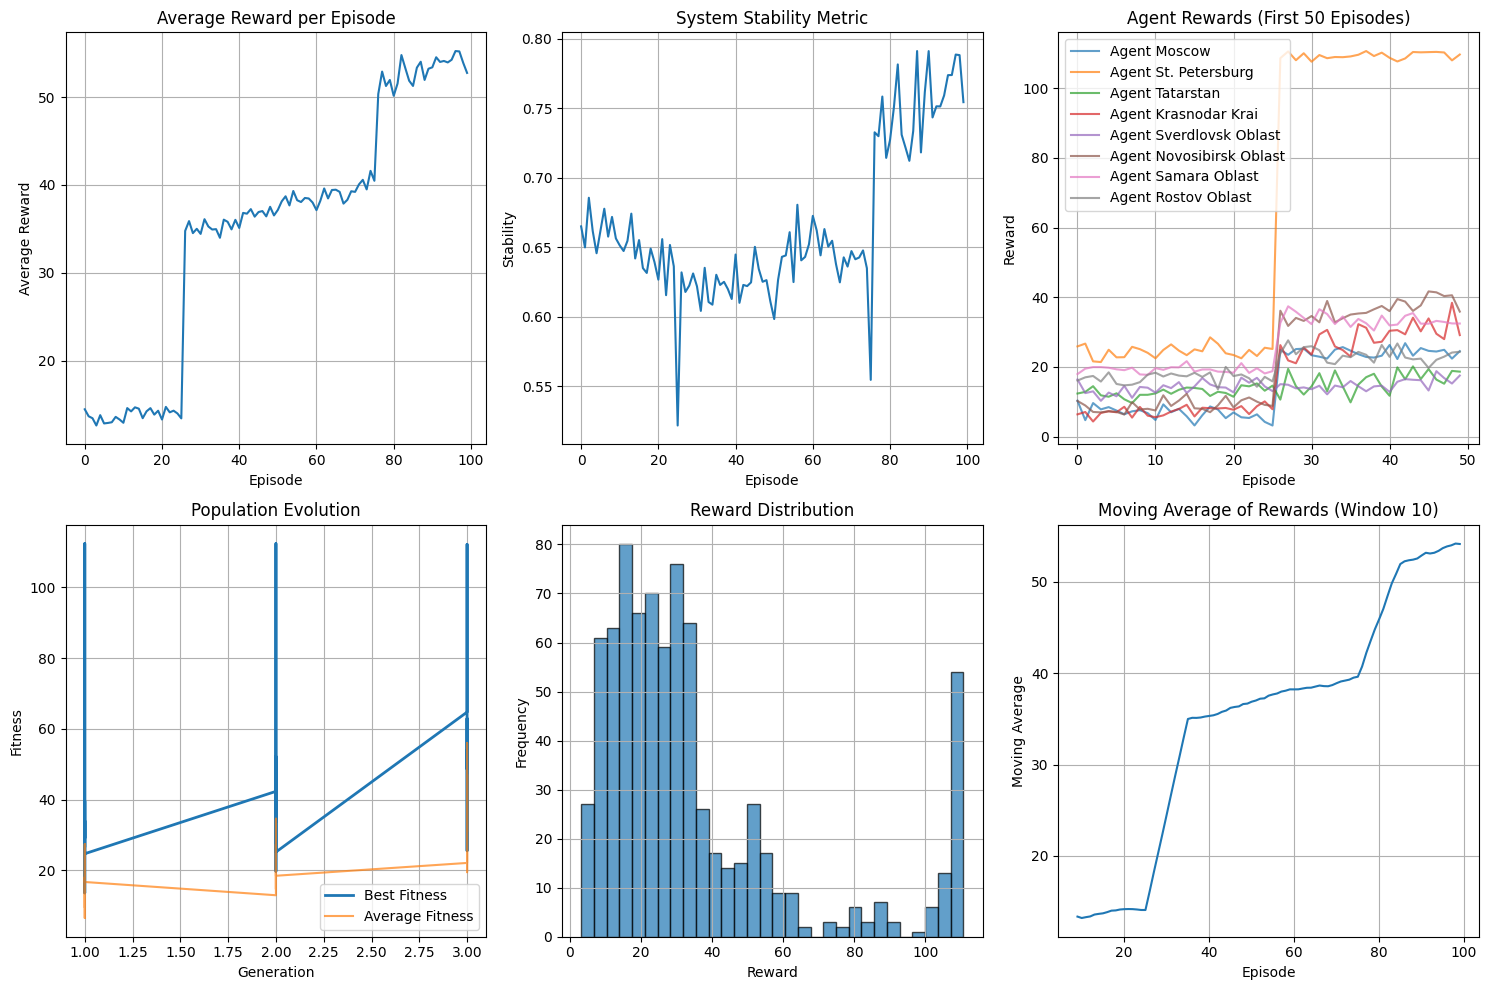

Results saved to maddpg_evolution_results_20250904_150205.csv

=== EXPERIMENT COMPLETED ===
Trained 8 agents
Results visualized and saved

=== FINAL ASSESSMENT ===
Region Moscow: final fitness = 68.847
Region St. Petersburg: final fitness = 111.164
Region Tatarstan: final fitness = 56.946
Region Krasnodar Krai: final fitness = 57.884
Region Sverdlovsk Oblast: final fitness = 31.710
Region Novosibirsk Oblast: final fitness = 66.367
Region Samara Oblast: final fitness = 52.138
Region Rostov Oblast: final fitness = 51.375
Mean final fitness: 62.054
Standard deviation: 21.369


In [18]:
# Demonstration of system usage (executed when the script is run as main)
if __name__ == "__main__":
    print("=== MULTI-AGENT REINFORCEMENT LEARNING SYSTEM ===")
    print("=== FOR DEMOGRAPHIC MODELING OF RUSSIAN REGIONS ===")
    print()
    # Synthetic data generation
    print("Generating synthetic data...")
    # Create a data generator
    data_generator = SyntheticDataGenerator(
        'russian_regions_demographic_data_2010_2024.csv', # Path to real data
        'crisis.txt' # Path to crisis scenarios
    )
    # Generate data for experiments
    years = list(range(2020, 2025)) # Years for generation
    # List of top regions for modeling
    top_regions = ['Moscow', 'St. Petersburg', 'Tatarstan', 'Krasnodar Krai',
                   'Sverdlovsk Oblast', 'Novosibirsk Oblast', 'Samara Oblast',
                   'Rostov Oblast', 'Bashkortostan', 'Chelyabinsk Oblast']
    # Generate synthetic data
    synthetic_data = data_generator.generate_synthetic_data(years, top_regions, apply_crisis=True)
    print(f"Generated {len(synthetic_data)} records for {len(top_regions)} regions")
    # Create the environment
    print("Creating multi-agent environment...")
    # Create a demographic environment with 8 regions and 30 steps per episode
    env = DemographicEnvironment(synthetic_data, n_regions=min(8, len(top_regions)), max_steps=30)
    print(f"Environment created for {env.n_regions} regions: {list(env.regions)}")
    # Start training
    print("Launching MADDPG experiment with evolutionary boosters...")
    # Run the main training function with reduced parameters for Colab
    trained_agents, experiment_logger = train_maddpg_with_evolution(
        env,
        n_episodes=100,  # Reduced number of episodes
        evolution_frequency=25, # Evolution optimization frequency
        population_size=8,  # Reduced population size
        save_results=True # Save results
    )
    print("\n=== EXPERIMENT COMPLETED ===")
    print(f"Trained {len(trained_agents)} agents")
    print("Results visualized and saved")
    # Final effectiveness assessment
    print("\n=== FINAL ASSESSMENT ===")
    final_rewards = [] # List for final rewards
    # Evaluate the fitness of each trained agent
    for region, agent in trained_agents.items():
        # Evaluate agent fitness over 5 episodes
        fitness = _evaluate_agent_fitness(agent, env, region, n_eval_episodes=5)
        final_rewards.append(fitness) # Add fitness to the list
        print(f"Region {region}: final fitness = {fitness:.3f}")
    # Print statistics on final rewards
    print(f"Mean final fitness: {np.mean(final_rewards):.3f}")
    print(f"Standard deviation: {np.std(final_rewards):.3f}")
